# Dissertation Notebook 02

# ISIC 2019: Dataset Exploration and Preparation

**Author:** Garry Da Costa  
**Supervisor:** Dr Deblina Bhattacharjee

---

## Introduction

This notebook examines the ISIC 2019 training data used in the diagnostic part of the project.

The metadata, diagnostic labels and image files are checked before the dataset used by the later modelling notebooks is prepared.





## Setup

### Imports and setup




In [4]:

import sys
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import PIL
from PIL import Image
import seaborn as sns
from google.colab import drive
from sklearn.model_selection import GroupShuffleSplit
import tarfile
import subprocess

### Software versions


In [5]:


print("=" * 67)
print(f"{'Software versions':^67}")
print("=" * 67, "\n")

print(f"Python: {sys.version.split()[0]}")
print(f"pandas: {pd.__version__}")
print(f"matplotlib: {matplotlib.__version__}")
print(f"Pillow: {PIL.__version__}")
print("seaborn:", sns.__version__)

                         Software versions                         

Python: 3.13.15
pandas: 2.2.3
matplotlib: 3.10.0
Pillow: 11.3.0
seaborn: 0.13.2


### Google Drive and paths


In [6]:
drive.mount(
    "/content/drive",
    force_remount=True
)

print("Google Drive mounted.")


ISIC_ROOT = Path(
    "/content/drive/MyDrive/Dissertation_Data/ISIC2019"
)

META_PATH = (
    ISIC_ROOT
    / "isic2019_metadata.csv"
)

FULL_IMAGE_DIR = (
    ISIC_ROOT
    / "images"
)

SPLIT_DIR = (
    ISIC_ROOT
    / "splits"
)


# tar creation

IMAGE_ARCHIVE_PATH = (
    ISIC_ROOT
    / "isic2019_fixed_split_images.tar"
)


print("\nISIC 2019 paths:")

print(
    "Dataset      :",
    ISIC_ROOT
)

print(
    "Metadata     :",
    META_PATH
)

print(
    "Images       :",
    FULL_IMAGE_DIR
)

print(
    "Splits       :",
    SPLIT_DIR
)

print(
    "Image archive:",
    IMAGE_ARCHIVE_PATH
)

Mounted at /content/drive
Google Drive mounted.

ISIC 2019 paths:
Dataset      : /content/drive/MyDrive/Dissertation_Data/ISIC2019
Metadata     : /content/drive/MyDrive/Dissertation_Data/ISIC2019/isic2019_metadata.csv
Images       : /content/drive/MyDrive/Dissertation_Data/ISIC2019/images
Splits       : /content/drive/MyDrive/Dissertation_Data/ISIC2019/splits
Image archive: /content/drive/MyDrive/Dissertation_Data/ISIC2019/isic2019_fixed_split_images.tar


In [7]:
required_paths = [
    ISIC_ROOT,
    META_PATH,
    FULL_IMAGE_DIR,
    SPLIT_DIR
]

for path in required_paths:
    if not path.exists():
        raise FileNotFoundError(f"Missing path: {path}")

print("\nAll required paths found.")


All required paths found.


## Section 1: Dataset

### 1.1 Load metadata

The ISIC 2019 metadata is loaded from Google Drive.


In [8]:


meta_df = pd.read_csv(META_PATH)

print("=" * 67)
print(f"{'ISIC 2019 metadata':^67}")
print("=" * 67, "\n")

print("Rows:", len(meta_df))
print("Columns:", len(meta_df.columns))
print("Unique image IDs:", meta_df["isic_id"].nunique())


                        ISIC 2019 metadata                         

Rows: 25331
Columns: 28
Unique image IDs: 25331


In [9]:
if len(meta_df) != 25331:
    raise ValueError(
        f"Expected 25331 rows, found {len(meta_df)}."
    )

if meta_df["isic_id"].isna().any():
    raise ValueError("Missing ISIC IDs found.")

if meta_df["isic_id"].duplicated().any():
    raise ValueError("Duplicate ISIC IDs found.")



### 1.2 Metadata structure

The metadata columns and data types are shown below.


In [10]:


column_summary = pd.DataFrame({
    "Column": meta_df.columns,
    "Data type": meta_df.dtypes.astype(str).values
})

display(column_summary)







,Column,Data type
0,isic_id,object
1,attribution,object
2,copyright_license,object
3,age_approx,float64
4,anatom_site_1,object
5,anatom_site_2,object
6,anatom_site_3,object
7,anatom_site_4,object
8,anatom_site_5,object
9,anatom_site_special,object


### 1.3 Diagnostic fields

The completeness of the diagnostic fields is checked below.


In [11]:


diagnosis_columns = [
    "diagnosis_1",
    "diagnosis_2",
    "diagnosis_3",
    "diagnosis_4",
    "diagnosis_5"
]

missing_columns = [
    column for column in diagnosis_columns
    if column not in meta_df.columns
]

if missing_columns:
    raise ValueError(
        f"Missing diagnostic columns: {missing_columns}"
    )

diagnosis_summary = pd.DataFrame({
    "Non-missing": meta_df[diagnosis_columns].notna().sum(),
    "Missing": meta_df[diagnosis_columns].isna().sum(),
    "Missing %": (
        meta_df[diagnosis_columns].isna().mean() * 100
    ).round(1),
    "Unique labels": meta_df[diagnosis_columns].nunique()
})

display(diagnosis_summary)

,Non-missing,Missing,Missing %,Unique labels
diagnosis_1,25331,0,0.0,3
diagnosis_2,25331,0,0.0,10
diagnosis_3,25076,255,1.0,13
diagnosis_4,976,24355,96.1,21
diagnosis_5,414,24917,98.4,5


`diagnosis_1` and `diagnosis_2` are complete. Missing values increase at the more detailed diagnostic levels.

## Section 2: Diagnostic labels

### 2.1 `diagnosis_1`

The first diagnostic level groups the records into broad diagnostic categories. Its class distribution is examined below.

In [12]:
##
## Check the diagnosis_1 distribution
##

diagnosis_1_counts = (
    meta_df["diagnosis_1"]
    .value_counts()
)

diagnosis_1_percentages = (
    meta_df["diagnosis_1"]
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
)

diagnosis_1_summary = pd.DataFrame({
    "Count": diagnosis_1_counts,
    "Percentage": diagnosis_1_percentages
})

display(diagnosis_1_summary)

if diagnosis_1_counts.sum() != len(meta_df):
    raise ValueError(
        "diagnosis_1 does not cover all metadata records."
    )


,Count,Percentage
diagnosis_1,,
Benign,15990,63.1
Malignant,8473,33.4
Indeterminate,868,3.4


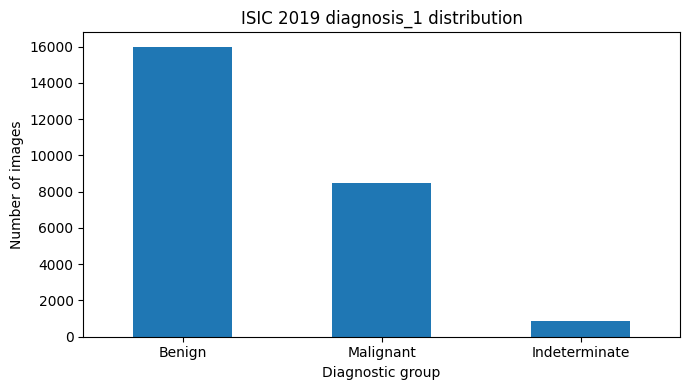

In [13]:

diagnosis_1_counts.plot(
    kind="bar",
    figsize=(7, 4)
)

plt.title("ISIC 2019 diagnosis_1 distribution")
plt.xlabel("Diagnostic group")
plt.ylabel("Number of images")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### Observation

`diagnosis_1` contains three broad groups. The distribution is uneven, with `Benign` containing the most records and `Indeterminate` containing substantially fewer records.

### 2.2 `diagnosis_2`

The second diagnostic level is also complete. It divides the records into more specific groups based on the type of proliferation.



In [14]:

##
## Check the diagnosis_2 distribution
##

diagnosis_2_counts = (
    meta_df["diagnosis_2"]
    .value_counts()
)

diagnosis_2_percentages = (
    meta_df["diagnosis_2"]
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
)

diagnosis_2_summary = pd.DataFrame({
    "Count": diagnosis_2_counts,
    "Percentage": diagnosis_2_percentages
})

display(diagnosis_2_summary)

if diagnosis_2_counts.sum() != len(meta_df):
    raise ValueError(
        "diagnosis_2 does not cover all metadata records."
    )






,Count,Percentage
diagnosis_2,,
Benign melanocytic proliferations,12871,50.8
Malignant melanocytic proliferations (Melanoma),4522,17.9
Malignant adnexal epithelial proliferations - Follicular,3323,13.1
Benign epidermal proliferations,2625,10.4
Indeterminate epidermal proliferations,867,3.4
Malignant epidermal proliferations,628,2.5
Benign soft tissue proliferations - Vascular,253,1.0
Benign soft tissue proliferations - Fibro-histiocytic,239,0.9
Collision - Only benign proliferations,2,0.0


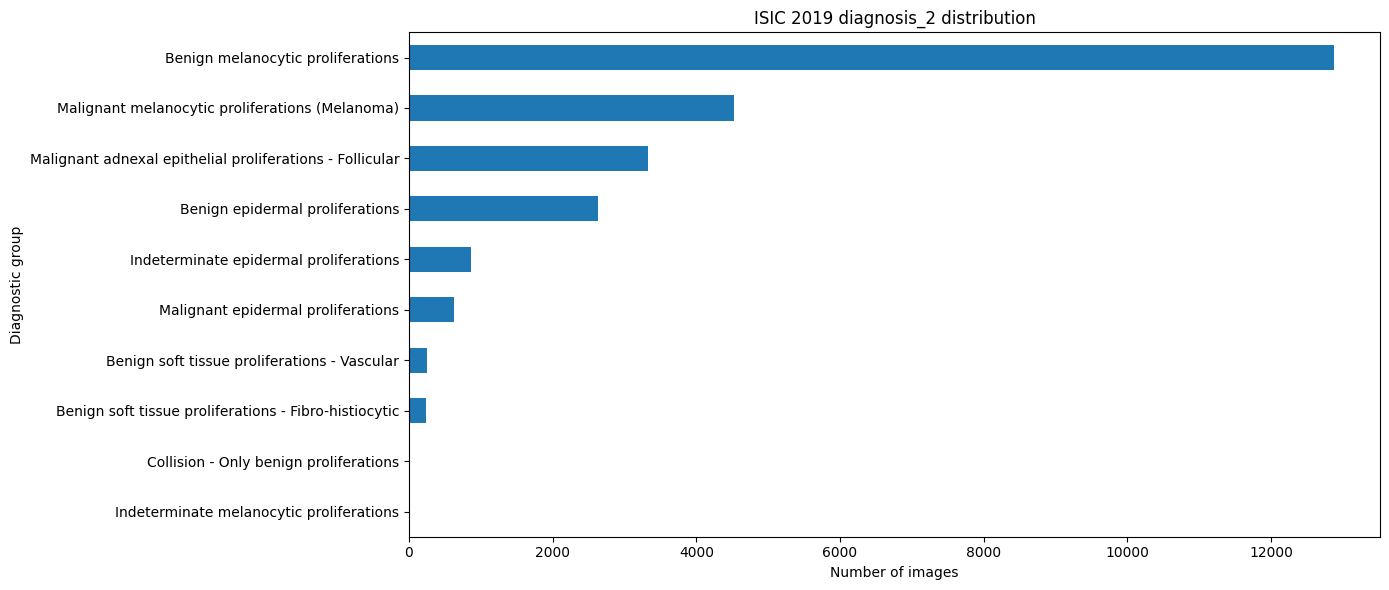

In [15]:
diagnosis_2_counts.sort_values().plot(
    kind="barh",
    figsize=(14, 6)
)

plt.title("ISIC 2019 diagnosis_2 distribution")
plt.xlabel("Number of images")
plt.ylabel("Diagnostic group")
plt.tight_layout()
plt.show()




#### Observation

`diagnosis_2` contains 10 groups and is also imbalanced. The largest group is benign melanocytic proliferation, while some categories contain very few records.

### 2.3 `diagnosis_3`

The third diagnostic level contains more specific diagnoses. Unlike the first two levels, some records do not have a `diagnosis_3` label.



In [16]:

##
## Check the diagnosis_3 distribution
##

diagnosis_3_values = (
    meta_df["diagnosis_3"]
    .fillna("Missing")
)

diagnosis_3_counts = (
    diagnosis_3_values
    .value_counts()
)

diagnosis_3_percentages = (
    diagnosis_3_values
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
)

diagnosis_3_summary = pd.DataFrame({
    "Count": diagnosis_3_counts,
    "Percentage": diagnosis_3_percentages
})

display(diagnosis_3_summary)

if diagnosis_3_counts.sum() != len(meta_df):
    raise ValueError(
        "diagnosis_3 record count does not match the metadata."
    )






,Count,Percentage
diagnosis_3,,
Nevus,12871,50.8
"Melanoma, NOS",4140,16.3
Basal cell carcinoma,3323,13.1
Seborrheic keratosis,1316,5.2
Pigmented benign keratosis,1099,4.3
Solar or actinic keratosis,867,3.4
"Squamous cell carcinoma, NOS",628,2.5
Missing,255,1.0
Dermatofibroma,239,0.9


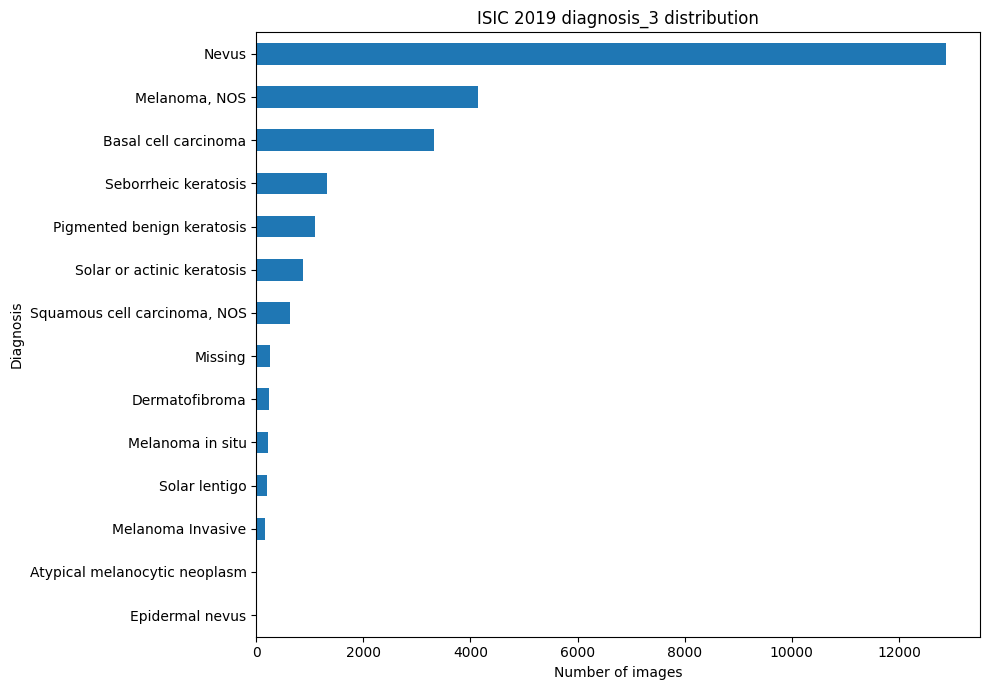

In [17]:

diagnosis_3_counts.sort_values().plot(
    kind="barh",
    figsize=(10, 7)
)

plt.title("ISIC 2019 diagnosis_3 distribution")
plt.xlabel("Number of images")
plt.ylabel("Diagnosis")
plt.tight_layout()
plt.show()


#### Observation

`diagnosis_3` contains more specific diagnoses and has a strong class imbalance. Nevus is the largest diagnosis, while several diagnoses are much less common. There are also 255 records without a `diagnosis_3` label.

### 2.4 Relationships between diagnostic levels

The three diagnostic levels are cross-tabulated to examine how the broader groups relate to the more detailed diagnoses.



In [18]:

##
## Cross-tabulate the diagnostic levels
##

diagnosis_3_for_tables = (
    meta_df["diagnosis_3"]
    .fillna("Missing")
)

diagnosis1_by_diagnosis2 = pd.crosstab(
    meta_df["diagnosis_1"],
    meta_df["diagnosis_2"]
)

diagnosis1_by_diagnosis3 = pd.crosstab(
    meta_df["diagnosis_1"],
    diagnosis_3_for_tables
)

diagnosis2_by_diagnosis3 = pd.crosstab(
    meta_df["diagnosis_2"],
    diagnosis_3_for_tables
)

#### `diagnosis_1` × `diagnosis_2`


In [19]:


display(diagnosis1_by_diagnosis2)



diagnosis_2,Benign epidermal proliferations,Benign melanocytic proliferations,Benign soft tissue proliferations - Fibro-histiocytic,Benign soft tissue proliferations - Vascular,Collision - Only benign proliferations,Indeterminate epidermal proliferations,Indeterminate melanocytic proliferations,Malignant adnexal epithelial proliferations - Follicular,Malignant epidermal proliferations,Malignant melanocytic proliferations (Melanoma)
diagnosis_1,,,,,,,,,,
Benign,2625,12871,239,253,2,0,0,0,0,0
Indeterminate,0,0,0,0,0,867,1,0,0,0
Malignant,0,0,0,0,0,0,0,3323,628,4522


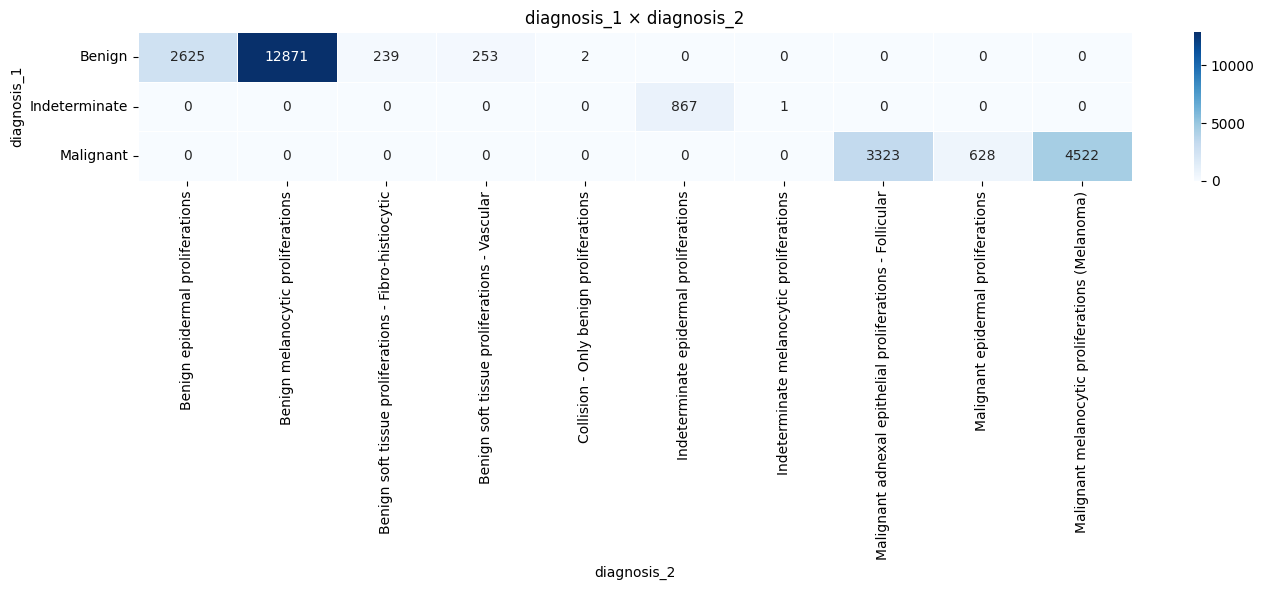

In [20]:
# Heatmap for diagnosis_1 × diagnosis_2

plt.figure(figsize=(14, 6))

sns.heatmap(
    diagnosis1_by_diagnosis2,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5
)

plt.title("diagnosis_1 × diagnosis_2")
plt.xlabel("diagnosis_2")
plt.ylabel("diagnosis_1")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

#### Observation

The `diagnosis_2` groups are nested within the broader `diagnosis_1` categories. Benign proliferation groups occur under `Benign`, indeterminate groups under `Indeterminate`, and malignant groups under `Malignant`.

#### `diagnosis_1` × `diagnosis_3`


In [21]:


display(diagnosis1_by_diagnosis3)

diagnosis_3,Atypical melanocytic neoplasm,Basal cell carcinoma,Dermatofibroma,Epidermal nevus,Melanoma Invasive,Melanoma in situ,"Melanoma, NOS",Missing,Nevus,Pigmented benign keratosis,Seborrheic keratosis,Solar lentigo,Solar or actinic keratosis,"Squamous cell carcinoma, NOS"
diagnosis_1,,,,,,,,,,,,,,
Benign,0,0,239,1,0,0,0,255,12871,1099,1316,209,0,0
Indeterminate,1,0,0,0,0,0,0,0,0,0,0,0,867,0
Malignant,0,3323,0,0,171,211,4140,0,0,0,0,0,0,628


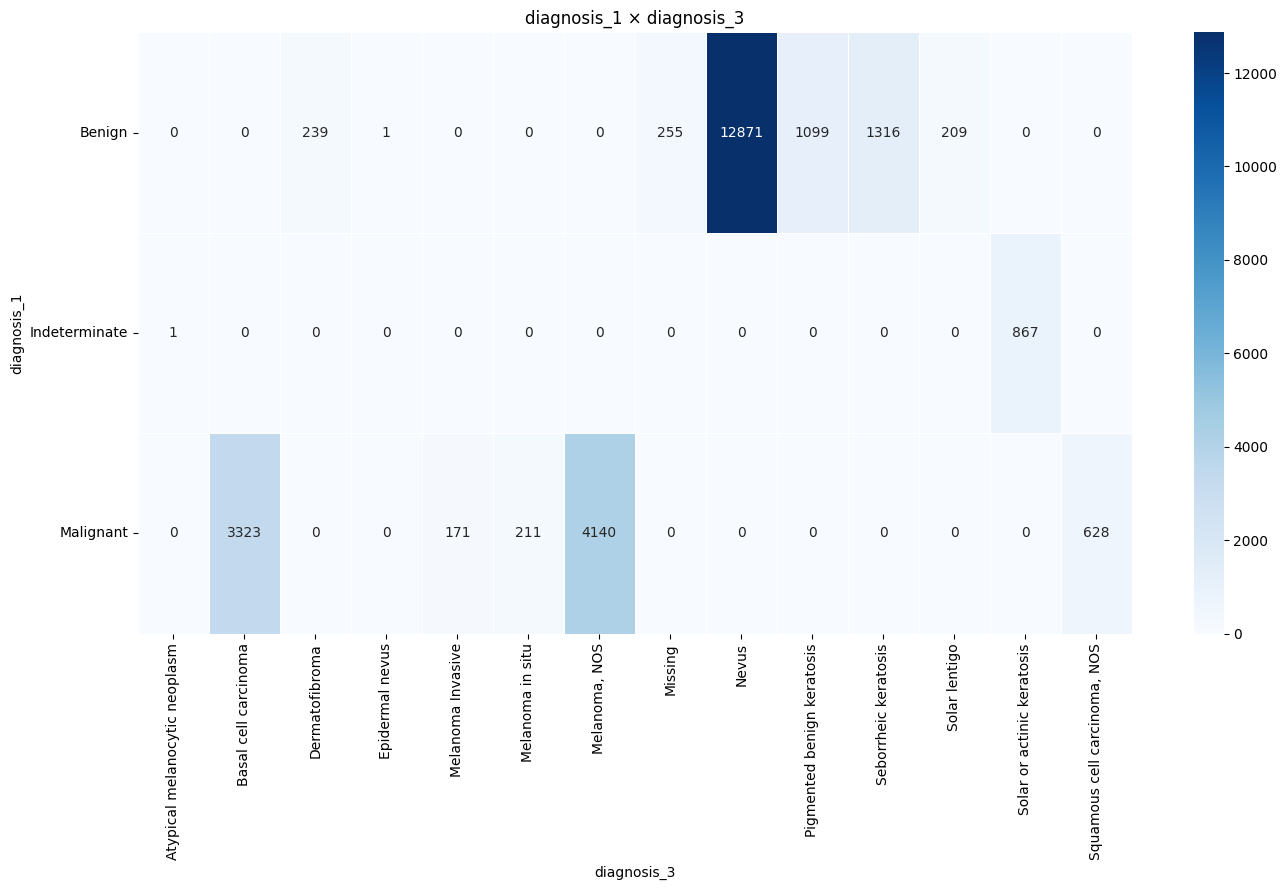

In [22]:

# Heatmap for diagnosis_1 × diagnosis_3

plt.figure(figsize=(14, 9))

sns.heatmap(
    diagnosis1_by_diagnosis3,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5
)

plt.title("diagnosis_1 × diagnosis_3")
plt.xlabel("diagnosis_3")
plt.ylabel("diagnosis_1")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()



#### `diagnosis_2` × `diagnosis_3`


In [23]:


display(diagnosis2_by_diagnosis3)

diagnosis_3,Atypical melanocytic neoplasm,Basal cell carcinoma,Dermatofibroma,Epidermal nevus,Melanoma Invasive,Melanoma in situ,"Melanoma, NOS",Missing,Nevus,Pigmented benign keratosis,Seborrheic keratosis,Solar lentigo,Solar or actinic keratosis,"Squamous cell carcinoma, NOS"
diagnosis_2,,,,,,,,,,,,,,
Benign epidermal proliferations,0,0,0,1,0,0,0,0,0,1099,1316,209,0,0
Benign melanocytic proliferations,0,0,0,0,0,0,0,0,12871,0,0,0,0,0
Benign soft tissue proliferations - Fibro-histiocytic,0,0,239,0,0,0,0,0,0,0,0,0,0,0
Benign soft tissue proliferations - Vascular,0,0,0,0,0,0,0,253,0,0,0,0,0,0
Collision - Only benign proliferations,0,0,0,0,0,0,0,2,0,0,0,0,0,0
Indeterminate epidermal proliferations,0,0,0,0,0,0,0,0,0,0,0,0,867,0
Indeterminate melanocytic proliferations,1,0,0,0,0,0,0,0,0,0,0,0,0,0
Malignant adnexal epithelial proliferations - Follicular,0,3323,0,0,0,0,0,0,0,0,0,0,0,0
Malignant epidermal proliferations,0,0,0,0,0,0,0,0,0,0,0,0,0,628


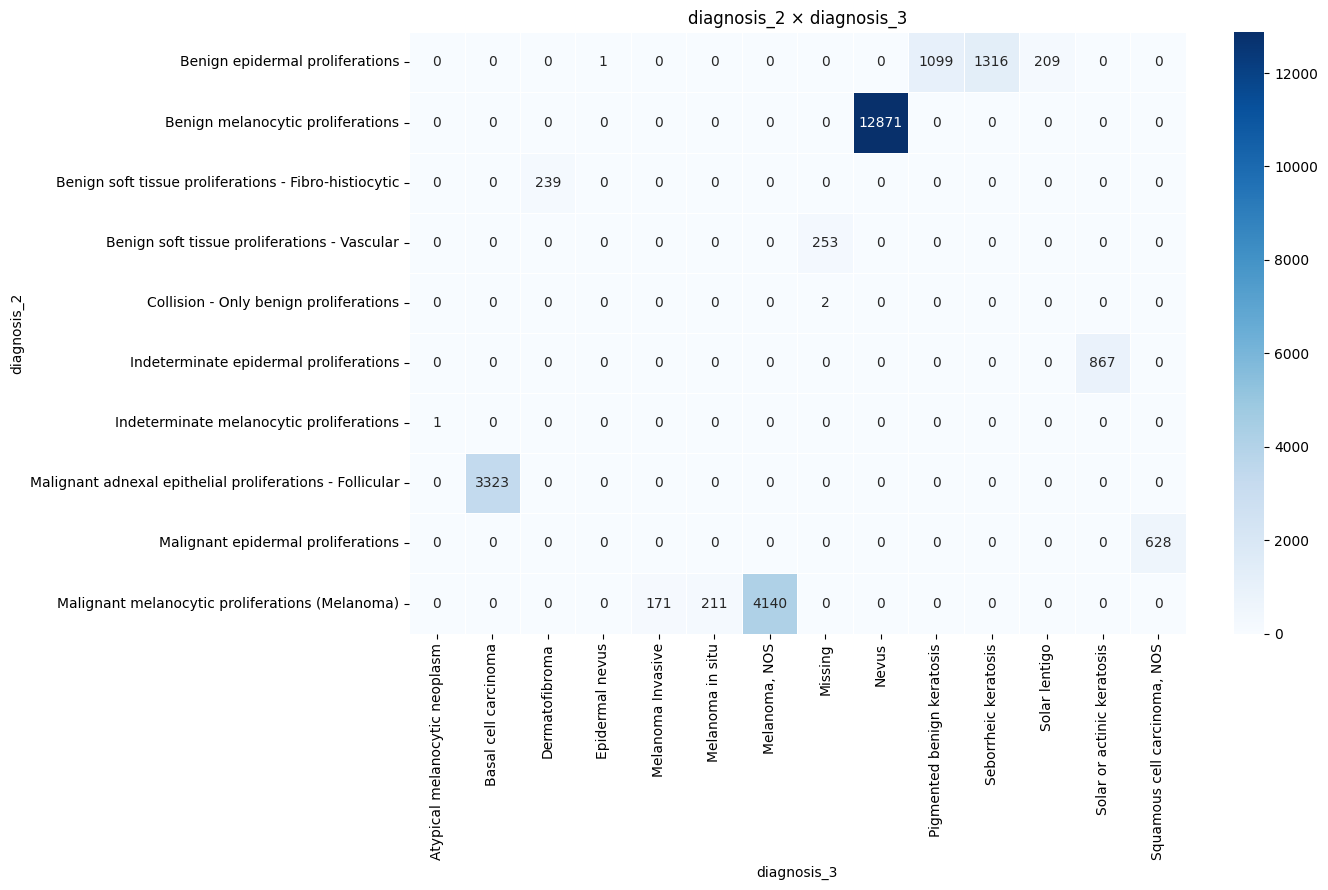

In [24]:
# Heatmap for diagnosis_2 × diagnosis_3

plt.figure(figsize=(14, 9))

sns.heatmap(
    diagnosis2_by_diagnosis3,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5
)

plt.title("diagnosis_2 × diagnosis_3")
plt.xlabel("diagnosis_3")
plt.ylabel("diagnosis_2")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

### 2.5 Melanoma and nevus diagnostic labels

The detailed nevus and melanoma labels in `diagnosis_3` are compared with `diagnosis_1`.

This checks whether these detailed labels follow the broader diagnostic groups. No target mapping is applied at this stage.

In [25]:

# Compare melanoma and nevus labels with diagnosis_1

melanoma_nevus_labels = [
    "Nevus",
    "Melanoma, NOS",
    "Melanoma in situ",
    "Melanoma Invasive"
]

melanoma_nevus_df = meta_df[
    meta_df["diagnosis_3"].isin(
        melanoma_nevus_labels
    )
].copy()

melanoma_nevus_table = pd.crosstab(
    melanoma_nevus_df["diagnosis_1"],
    melanoma_nevus_df["diagnosis_3"]
)

display(melanoma_nevus_table)

diagnosis_3,Melanoma Invasive,Melanoma in situ,"Melanoma, NOS",Nevus
diagnosis_1,,,,
Benign,0,0,0,12871
Malignant,171,211,4140,0


In [26]:
label_group_counts = (
    melanoma_nevus_df
    .groupby("diagnosis_3")["diagnosis_1"]
    .nunique()
)

print(
    "Labels linked to more than one diagnosis_1 group:",
    (label_group_counts > 1).sum()
)

if (label_group_counts > 1).any():
    raise ValueError(
        "A melanoma or nevus label maps to more than one diagnosis_1 group."
    )

Labels linked to more than one diagnosis_1 group: 0



#### Interpretation

`Nevus` is recorded as `Benign` in `diagnosis_1`, while `Melanoma, NOS`, `Melanoma in situ` and `Melanoma Invasive` are recorded as `Malignant`.

None of these four `diagnosis_3` labels occurs under more than one `diagnosis_1` group. The detailed melanoma and nevus labels are therefore consistent with the broader benign and malignant grouping in the observed metadata.

### 2.6 Comparison of candidate diagnostic levels

The three diagnostic levels are compared in terms of label coverage, number of classes and class imbalance.


In [27]:

diagnostic_comparison = pd.DataFrame({
    "Classes": [
        meta_df["diagnosis_1"].nunique(),
        meta_df["diagnosis_2"].nunique(),
        meta_df["diagnosis_3"].nunique()
    ],
    "Missing": [
        meta_df["diagnosis_1"].isna().sum(),
        meta_df["diagnosis_2"].isna().sum(),
        meta_df["diagnosis_3"].isna().sum()
    ],
    "Smallest class": [
        meta_df["diagnosis_1"].value_counts().min(),
        meta_df["diagnosis_2"].value_counts().min(),
        meta_df["diagnosis_3"].value_counts().min()
    ],
    "Largest class": [
        meta_df["diagnosis_1"].value_counts().max(),
        meta_df["diagnosis_2"].value_counts().max(),
        meta_df["diagnosis_3"].value_counts().max()
    ]
}, index=[
    "diagnosis_1",
    "diagnosis_2",
    "diagnosis_3"
])

diagnostic_comparison["Largest / smallest"] = (
    diagnostic_comparison["Largest class"]
    / diagnostic_comparison["Smallest class"]
).round(1)

display(diagnostic_comparison)

,Classes,Missing,Smallest class,Largest class,Largest / smallest
diagnosis_1,3,0,868,15990,18.4
diagnosis_2,10,0,1,12871,12871.0
diagnosis_3,13,255,1,12871,12871.0


#### Inference

`diagnosis_1` has three complete broad classes. `diagnosis_2` and `diagnosis_3` contain more specific labels, but also include very small classes. `diagnosis_3` also has 255 missing values.

For this reason, `diagnosis_1` is the simpler and more complete option for the main diagnostic target.

### 2.7 Diagnostic target selection

The diagnostic levels represent different levels of granularity rather than conflicting label systems. `diagnosis_1` is complete for all 25,331 records and contains three broad groups. In comparison, `diagnosis_2` contains 10 classes, while `diagnosis_3` contains 13 classes, has 255 missing labels, and both finer levels include classes represented by only one or two records.

The diagnostic hierarchy also shows that `Nevus` is consistently grouped as `Benign`, while `Melanoma, NOS`, `Melanoma in situ` and `Melanoma Invasive` are consistently grouped as `Malignant`. No conflicting `diagnosis_1` labels were observed for these four detailed diagnoses.

For this project, `diagnosis_1` is therefore selected as the primary diagnostic target. It retains the full dataset, avoids the severe class sparsity of the finer diagnostic levels, and preserves the broad benign, indeterminate and malignant distinction. `Indeterminate` is retained as a separate class.


In [28]:


##
## Define and check the primary diagnostic target
##

PRIMARY_TARGET = "diagnosis_1"

EXPECTED_CLASSES = [
    "Benign",
    "Indeterminate",
    "Malignant"
]

observed_classes = sorted(
    meta_df[PRIMARY_TARGET]
    .dropna()
    .unique()
)

print("=" * 67)
print(f"{'Primary diagnostic target':^67}")
print("=" * 67, "\n")

print("Target:", PRIMARY_TARGET)
print("Classes:", observed_classes)
print("Missing labels:", meta_df[PRIMARY_TARGET].isna().sum())

if meta_df[PRIMARY_TARGET].isna().any():
    raise ValueError(
        "Missing primary target labels found."
    )

if observed_classes != sorted(EXPECTED_CLASSES):
    raise ValueError(
        f"Unexpected target classes: {observed_classes}"
    )

                     Primary diagnostic target                     

Target: diagnosis_1
Classes: ['Benign', 'Indeterminate', 'Malignant']
Missing labels: 0


## Section 3: Image Check

### 3.1 Image files

The image filenames are compared with the metadata identifiers.


In [29]:
# Compare image files with metadata IDs

image_files = sorted(
    FULL_IMAGE_DIR.glob("*.jpg")
)

metadata_ids = set(
    meta_df["isic_id"]
)

image_ids = {
    image_path.stem
    for image_path in image_files
}

missing_image_ids = metadata_ids - image_ids
unexpected_image_ids = image_ids - metadata_ids

image_check = pd.DataFrame({
    "Check": [
        "Image files",
        "Missing image IDs",
        "Unexpected image IDs"
    ],
    "Count": [
        len(image_files),
        len(missing_image_ids),
        len(unexpected_image_ids)
    ]
})

display(image_check)

if missing_image_ids:
    raise ValueError(
        f"Missing image files: {len(missing_image_ids)}"
    )

if unexpected_image_ids:
    raise ValueError(
        f"Unexpected image files: {len(unexpected_image_ids)}"
    )

,Check,Count
0,Image files,25331
1,Missing image IDs,0
2,Unexpected image IDs,0


### 3.2 Sample image check

A small sample is opened to check that the selected image files can be read.



In [30]:

# Check a small deterministic sample

sample_files = image_files[:8]

unreadable = []

for image_path in sample_files:
    try:
        with Image.open(image_path) as image:
            image.load()
    except Exception:
        unreadable.append(image_path.name)

if unreadable:
    raise ValueError(
        f"Unreadable sample images: {unreadable}"
    )

### 3.3 Sample images

The same sample is displayed for a visual check of the image data.



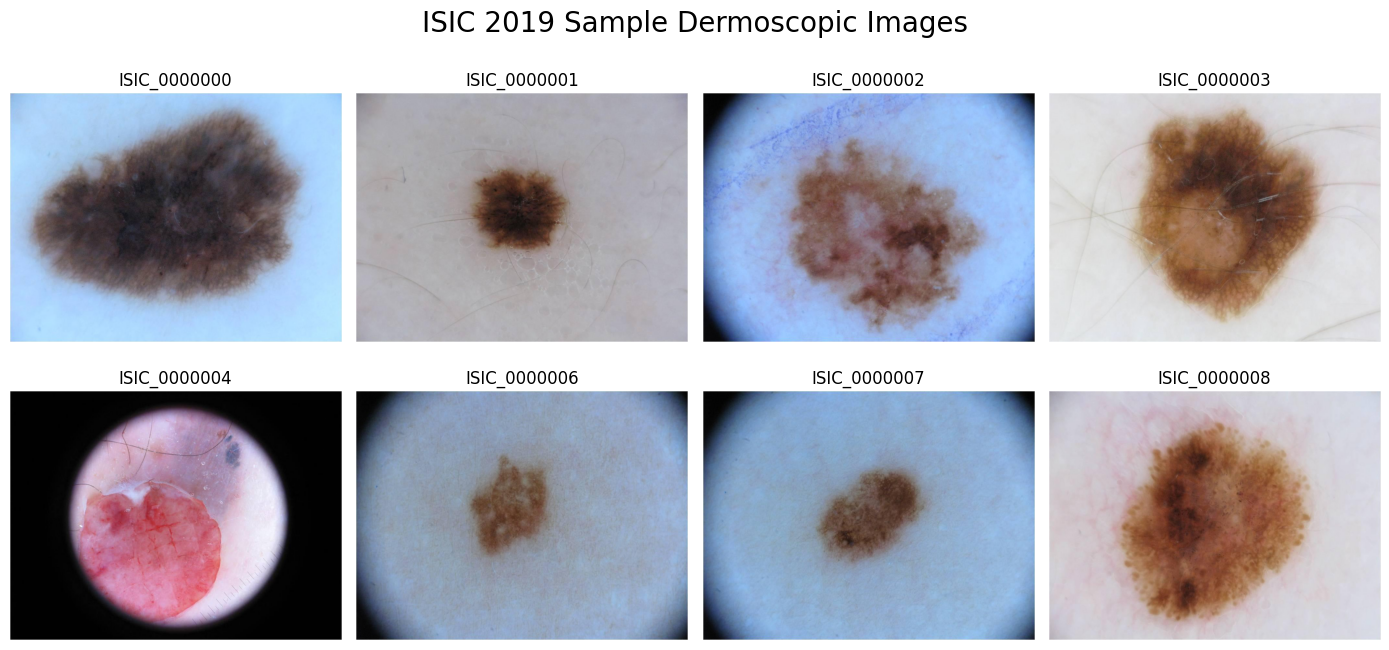

In [31]:

# Display the sample images

fig, axes = plt.subplots(
    2,
    4,
    figsize=(14, 7)
)

for ax, image_path in zip(axes.flat, sample_files):
    with Image.open(image_path) as image:
        ax.imshow(image)

    ax.set_title(image_path.stem)
    ax.axis("off")

fig.suptitle("ISIC 2019 Sample Dermoscopic Images", size=20)
plt.tight_layout()
plt.show()

## Section 4: Fixed Dataset Split

### 4.1 Grouping information

Lesion and patient identifiers are checked because repeated images from the same lesion or patient can affect dataset separation.



In [32]:

# Check lesion and patient identifier information

lesion_counts = (
    meta_df["lesion_id"]
    .dropna()
    .value_counts()
)

multi_image_lesions = (
    lesion_counts > 1
).sum()

images_in_multi_image_lesions = (
    lesion_counts[
        lesion_counts > 1
    ]
    .sum()
)

patient_records = meta_df[
    meta_df["patient_id"].notna()
]

grouping_summary = pd.DataFrame({
    "Measure": [
        "Unique lesion IDs",
        "Lesions with multiple images",
        "Images in multi-image lesions",
        "Records with patient_id",
        "Unique patient IDs"
    ],
    "Count": [
        len(lesion_counts),
        multi_image_lesions,
        images_in_multi_image_lesions,
        len(patient_records),
        patient_records["patient_id"].nunique()
    ]
})

display(grouping_summary)



,Measure,Count
0,Unique lesion IDs,12264
1,Lesions with multiple images,5059
2,Images in multi-image lesions,16459
3,Records with patient_id,417
4,Unique patient IDs,369


In [33]:

# Check target consistency within lesions

lesion_target_counts = (
    meta_df[
        meta_df["lesion_id"].notna()
    ]
    .groupby("lesion_id")[PRIMARY_TARGET]
    .nunique()
)

if (lesion_target_counts > 1).any():
    raise ValueError(
        "A lesion contains more than one primary target label."
    )

### 4.2 Reproduce the fixed split

The dataset split is reproduced using `lesion_id` as the grouping identifier. Where `lesion_id` is missing, the unique `isic_id` is used instead.

A fixed random state of 42 is used so that the same partition can be reproduced.

In [34]:
# Reproduce the fixed dataset split

SPLIT_RANDOM_STATE = 42

group_id = meta_df["lesion_id"].copy()

missing_group = group_id.isna()

group_id.loc[missing_group] = (
    meta_df.loc[missing_group, "isic_id"]
)

# Training: approximately 70%
splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.30,
    random_state=SPLIT_RANDOM_STATE
)

train_idx, temp_idx = next(
    splitter.split(
        meta_df,
        groups=group_id
    )
)

generated_train_df = meta_df.iloc[
    train_idx
].copy()

temp_df = meta_df.iloc[
    temp_idx
].copy()

temp_group_id = group_id.iloc[
    temp_idx
].to_numpy()

# Validation and test: approximately 15% each
splitter_valid_test = GroupShuffleSplit(
    n_splits=1,
    test_size=0.50,
    random_state=SPLIT_RANDOM_STATE
)

validation_idx, test_idx = next(
    splitter_valid_test.split(
        temp_df,
        groups=temp_group_id
    )
)

generated_validation_df = temp_df.iloc[
    validation_idx
].copy()

generated_test_df = temp_df.iloc[
    test_idx
].copy()

### 4.3 Save the current split

The reproduced training, validation and test partitions are saved to Google Drive.

The saved files retain the original ISIC 2019 metadata columns, including `diagnosis_1`, `diagnosis_2` and `diagnosis_3`. `diagnosis_1` remains the primary model target. The finer diagnostic fields are retained as metadata for later evaluation and do not become additional training targets.

Saving the partitions here ensures that the later modelling notebooks use the split produced by this version of Notebook 02 rather than relying on previously saved CSV files.



In [35]:

##
## Save the current ISIC 2019 split
##

SPLIT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

generated_train_df.to_csv(
    SPLIT_DIR / "train.csv",
    index=False
)

generated_validation_df.to_csv(
    SPLIT_DIR / "validation.csv",
    index=False
)

generated_test_df.to_csv(
    SPLIT_DIR / "test.csv",
    index=False
)

all_splits_df = pd.concat(
    [
        generated_train_df.assign(split="train"),
        generated_validation_df.assign(split="validation"),
        generated_test_df.assign(split="test"),
    ],
    ignore_index=True
)

all_splits_df.to_csv(
    SPLIT_DIR / "all_splits.csv",
    index=False
)

print("Current ISIC 2019 split saved.")
print()
print(f"Train      : {SPLIT_DIR / 'train.csv'}")
print(f"Validation : {SPLIT_DIR / 'validation.csv'}")
print(f"Test       : {SPLIT_DIR / 'test.csv'}")
print(f"All splits : {SPLIT_DIR / 'all_splits.csv'}")




Current ISIC 2019 split saved.

Train      : /content/drive/MyDrive/Dissertation_Data/ISIC2019/splits/train.csv
Validation : /content/drive/MyDrive/Dissertation_Data/ISIC2019/splits/validation.csv
Test       : /content/drive/MyDrive/Dissertation_Data/ISIC2019/splits/test.csv
All splits : /content/drive/MyDrive/Dissertation_Data/ISIC2019/splits/all_splits.csv




### 4.4 Verify the saved split and diagnostic metadata

The newly saved CSV files are loaded again from Google Drive.

This check confirms that:

1. each file can be read after saving;
2. `isic_id` is retained;
3. `diagnosis_1`, `diagnosis_2` and `diagnosis_3` are retained;
5. `diagnosis_1` remains complete in every partition;
6. `diagnosis_2` remains available for later melanoma-specific evaluation;
 saving and reloading the files has not changed the number or ordering of records.

The presence of `diagnosis_2` and `diagnosis_3` does not make them model targets. The baseline and MTL diagnostic heads continue to use `diagnosis_1`.


In [36]:
##
## Reload and verify the newly saved split
##

saved_train_df = pd.read_csv(
    SPLIT_DIR / "train.csv"
)

saved_validation_df = pd.read_csv(
    SPLIT_DIR / "validation.csv"
)

saved_test_df = pd.read_csv(
    SPLIT_DIR / "test.csv"
)

saved_all_splits_df = pd.read_csv(
    SPLIT_DIR / "all_splits.csv"
)

saved_splits = {
    "Training": saved_train_df,
    "Validation": saved_validation_df,
    "Test": saved_test_df,
}

generated_splits = {
    "Training": generated_train_df,
    "Validation": generated_validation_df,
    "Test": generated_test_df,
}

REQUIRED_SAVED_COLUMNS = [
    "isic_id",
    "diagnosis_1",
    "diagnosis_2",
    "diagnosis_3",
]

print("=" * 70)
print(f"{'SAVED SPLIT VERIFICATION':^70}")
print("=" * 70)

for split_name in generated_splits:

    generated_df = generated_splits[split_name]
    saved_df = saved_splits[split_name]

    print(f"\n{split_name}")
    print("-" * 70)

    missing_columns = [
        column
        for column in REQUIRED_SAVED_COLUMNS
        if column not in saved_df.columns
    ]

    if missing_columns:
        raise ValueError(
            f"{split_name} is missing required columns: "
            f"{missing_columns}"
        )

    if len(generated_df) != len(saved_df):
        raise ValueError(
            f"{split_name} row count changed after saving."
        )

    if (
        generated_df["isic_id"].tolist()
        != saved_df["isic_id"].tolist()
    ):
        raise ValueError(
            f"{split_name} isic_id ordering changed after saving."
        )

    print(f"Rows            : {len(saved_df):,}")
    print(f"Columns         : {saved_df.shape[1]}")
    print("isic_id         : PRESENT")
    print("diagnosis_1     : PRESENT")
    print("diagnosis_2     : PRESENT")
    print("diagnosis_3     : PRESENT")

    print(
        f"diagnosis_1 NaN : "
        f"{saved_df['diagnosis_1'].isna().sum():,}"
    )

    print(
        f"diagnosis_2 NaN : "
        f"{saved_df['diagnosis_2'].isna().sum():,}"
    )

    print(
        f"diagnosis_3 NaN : "
        f"{saved_df['diagnosis_3'].isna().sum():,}"
    )

    if saved_df["diagnosis_1"].isna().any():
        raise ValueError(
            f"{split_name} contains missing diagnosis_1 values."
        )

print("\n" + "=" * 70)
print("Saved split verification passed.")
print("=" * 70)

                       SAVED SPLIT VERIFICATION                       

Training
----------------------------------------------------------------------
Rows            : 17,672
Columns         : 28
isic_id         : PRESENT
diagnosis_1     : PRESENT
diagnosis_2     : PRESENT
diagnosis_3     : PRESENT
diagnosis_1 NaN : 0
diagnosis_2 NaN : 0
diagnosis_3 NaN : 186

Validation
----------------------------------------------------------------------
Rows            : 3,808
Columns         : 28
isic_id         : PRESENT
diagnosis_1     : PRESENT
diagnosis_2     : PRESENT
diagnosis_3     : PRESENT
diagnosis_1 NaN : 0
diagnosis_2 NaN : 0
diagnosis_3 NaN : 22

Test
----------------------------------------------------------------------
Rows            : 3,851
Columns         : 28
isic_id         : PRESENT
diagnosis_1     : PRESENT
diagnosis_2     : PRESENT
diagnosis_3     : PRESENT
diagnosis_1 NaN : 0
diagnosis_2 NaN : 0
diagnosis_3 NaN : 47

Saved split verification passed.


In [37]:
##
## Reload and verify the newly saved split
##

saved_train_df = pd.read_csv(
    SPLIT_DIR / "train.csv"
)

saved_validation_df = pd.read_csv(
    SPLIT_DIR / "validation.csv"
)

saved_test_df = pd.read_csv(
    SPLIT_DIR / "test.csv"
)

saved_all_splits_df = pd.read_csv(
    SPLIT_DIR / "all_splits.csv"
)

saved_splits = {
    "Training": saved_train_df,
    "Validation": saved_validation_df,
    "Test": saved_test_df,
}

generated_splits = {
    "Training": generated_train_df,
    "Validation": generated_validation_df,
    "Test": generated_test_df,
}

REQUIRED_SAVED_COLUMNS = [
    "isic_id",
    "diagnosis_1",
    "diagnosis_2",
    "diagnosis_3",
]

print("=" * 70)
print(f"{'SAVED SPLIT VERIFICATION':^70}")
print("=" * 70)

for split_name in generated_splits:

    generated_df = generated_splits[split_name]
    saved_df = saved_splits[split_name]

    print(f"\n{split_name}")
    print("-" * 70)

    missing_columns = [
        column
        for column in REQUIRED_SAVED_COLUMNS
        if column not in saved_df.columns
    ]

    if missing_columns:
        raise ValueError(
            f"{split_name} is missing required columns: "
            f"{missing_columns}"
        )

    if len(generated_df) != len(saved_df):
        raise ValueError(
            f"{split_name} row count changed after saving."
        )

    if (
        generated_df["isic_id"].tolist()
        != saved_df["isic_id"].tolist()
    ):
        raise ValueError(
            f"{split_name} isic_id ordering changed after saving."
        )

    print(f"Rows            : {len(saved_df):,}")
    print(f"Columns         : {saved_df.shape[1]}")
    print("isic_id         : PRESENT")
    print("diagnosis_1     : PRESENT")
    print("diagnosis_2     : PRESENT")
    print("diagnosis_3     : PRESENT")

    print(
        f"diagnosis_1 NaN : "
        f"{saved_df['diagnosis_1'].isna().sum():,}"
    )

    print(
        f"diagnosis_2 NaN : "
        f"{saved_df['diagnosis_2'].isna().sum():,}"
    )

    print(
        f"diagnosis_3 NaN : "
        f"{saved_df['diagnosis_3'].isna().sum():,}"
    )

    if saved_df["diagnosis_1"].isna().any():
        raise ValueError(
            f"{split_name} contains missing diagnosis_1 values."
        )

print("\n" + "=" * 70)
print("Saved split verification passed.")
print("=" * 70)

                       SAVED SPLIT VERIFICATION                       

Training
----------------------------------------------------------------------
Rows            : 17,672
Columns         : 28
isic_id         : PRESENT
diagnosis_1     : PRESENT
diagnosis_2     : PRESENT
diagnosis_3     : PRESENT
diagnosis_1 NaN : 0
diagnosis_2 NaN : 0
diagnosis_3 NaN : 186

Validation
----------------------------------------------------------------------
Rows            : 3,808
Columns         : 28
isic_id         : PRESENT
diagnosis_1     : PRESENT
diagnosis_2     : PRESENT
diagnosis_3     : PRESENT
diagnosis_1 NaN : 0
diagnosis_2 NaN : 0
diagnosis_3 NaN : 22

Test
----------------------------------------------------------------------
Rows            : 3,851
Columns         : 28
isic_id         : PRESENT
diagnosis_1     : PRESENT
diagnosis_2     : PRESENT
diagnosis_3     : PRESENT
diagnosis_1 NaN : 0
diagnosis_2 NaN : 0
diagnosis_3 NaN : 47

Saved split verification passed.


### 4.5 Verify the saved split

The reproduced partition is compared with the saved training, validation and test files used by the later modelling notebooks.



In [38]:
# Use the newly saved and verified partitions from this point onwards

train_df = saved_train_df
validation_df = saved_validation_df
test_df = saved_test_df

splits = {
    "Training": train_df,
    "Validation": validation_df,
    "Test": test_df,
}

split_summary = pd.DataFrame({
    "Split": splits.keys(),
    "Records": [
        len(split_df)
        for split_df in splits.values()
    ],
})

display(split_summary)

,Split,Records
0,Training,17672
1,Validation,3808
2,Test,3851


### 4.6 Split integrity

Image, lesion and available patient identifiers are compared across the three partitions. Image and identified-lesion overlap are treated as split errors. Patient overlap is reported separately because patient identifiers are incomplete.


In [39]:


# Prepare identifier sets

train_ids = set(
    train_df["isic_id"]
)

validation_ids = set(
    validation_df["isic_id"]
)

test_ids = set(
    test_df["isic_id"]
)

train_lesions = set(
    train_df["lesion_id"].dropna()
)

validation_lesions = set(
    validation_df["lesion_id"].dropna()
)

test_lesions = set(
    test_df["lesion_id"].dropna()
)

train_patients = set(
    train_df["patient_id"].dropna()
)

validation_patients = set(
    validation_df["patient_id"].dropna()
)

test_patients = set(
    test_df["patient_id"].dropna()
)



In [40]:
# Compare identifiers across partitions

overlap_summary = pd.DataFrame({
    "Identifier": [
        "isic_id",
        "lesion_id",
        "patient_id"
    ],
    "Training / validation": [
        len(train_ids & validation_ids),
        len(train_lesions & validation_lesions),
        len(train_patients & validation_patients)
    ],
    "Training / test": [
        len(train_ids & test_ids),
        len(train_lesions & test_lesions),
        len(train_patients & test_patients)
    ],
    "Validation / test": [
        len(validation_ids & test_ids),
        len(validation_lesions & test_lesions),
        len(validation_patients & test_patients)
    ]
})

display(overlap_summary)

,Identifier,Training / validation,Training / test,Validation / test
0,isic_id,0,0,0
1,lesion_id,0,0,0
2,patient_id,8,7,2


In [41]:

# Protect image and lesion separation

if (
    train_ids & validation_ids
    or train_ids & test_ids
    or validation_ids & test_ids
):
    raise ValueError(
        "Image overlap found between dataset splits."
    )

if (
    train_lesions & validation_lesions
    or train_lesions & test_lesions
    or validation_lesions & test_lesions
):
    raise ValueError(
        "Lesion overlap found between dataset splits."
    )

split_ids = (
    train_ids
    | validation_ids
    | test_ids
)

if split_ids != metadata_ids:
    raise ValueError(
        "Split image IDs do not match the metadata IDs."
    )

for split_name, split_df in splits.items():
    if split_df["isic_id"].duplicated().any():
        raise ValueError(
            f"Duplicate image IDs found in {split_name}."
        )


### 4.7 Target distribution across splits

The selected diagnostic target is checked across the fixed training, validation and test partitions.



In [42]:

# Compare target distribution across partitions

split_target_summary = pd.DataFrame(
    index=EXPECTED_CLASSES
)

for split_name, split_df in splits.items():

    counts = (
        split_df[PRIMARY_TARGET]
        .value_counts()
        .reindex(EXPECTED_CLASSES)
    )

    percentages = (
        split_df[PRIMARY_TARGET]
        .value_counts(normalize=True)
        .mul(100)
        .reindex(EXPECTED_CLASSES)
        .round(1)
    )

    split_target_summary[
        f"{split_name} count"
    ] = counts

    split_target_summary[
        f"{split_name} %"
    ] = percentages

display(split_target_summary)

if split_target_summary.isna().any().any():
    raise ValueError(
        "A target class is missing from one or more dataset splits."
    )

,Training count,Training %,Validation count,Validation %,Test count,Test %
Benign,11195,63.3,2391,62.8,2404,62.4
Indeterminate,600,3.4,138,3.6,130,3.4
Malignant,5877,33.3,1279,33.6,1317,34.2


### 4.8 Prepare the reusable image archive

The images required by the fixed training, validation and test partitions are stored in a single TAR archive.

This archive is created once during data preparation and is reused by the later baseline and multi-task training notebooks. Before it is used, its image IDs are checked against the fixed split.

In [43]:
## Identify images required by the fixed split


required_id_series = pd.concat(
    [
        train_df["isic_id"],
        validation_df["isic_id"],
        test_df["isic_id"],
    ],
    ignore_index=True
)

if required_id_series.isna().any():

    raise ValueError(
        "Missing image IDs found "
        "in the fixed split."
    )


required_ids = (
    required_id_series
    .astype(str)
    .unique()
)

required_ids_sorted = sorted(
    required_ids
)


missing_archive_images = [
    isic_id
    for isic_id in required_ids_sorted
    if not (
        FULL_IMAGE_DIR
        / f"{isic_id}.jpg"
    ).exists()
]


print("=" * 67)
print(f"{'Fixed-split image archive':^67}")
print("=" * 67, "\n")

print(
    f"Required images : "
    f"{len(required_ids_sorted):,}"
)

print(
    f"Missing images  : "
    f"{len(missing_archive_images):,}"
)


if missing_archive_images:

    raise FileNotFoundError(
        f"{len(missing_archive_images):,} "
        "required image files are missing."
    )



                     Fixed-split image archive                     

Required images : 25,331
Missing images  : 0


In [44]:
##
## Create the reusable image archive
##

if IMAGE_ARCHIVE_PATH.exists():

    print(
        "Image archive already exists. "
        "It will be verified rather than recreated."
    )


else:

    print("=" * 67)
    print(f"{'Create ISIC 2019 image archive':^67}")
    print("=" * 67, "\n")

    print(
        f"Source images : {FULL_IMAGE_DIR}"
    )

    print(
        f"Images        : {len(required_ids_sorted):,}"
    )

    print(
        f"Archive       : {IMAGE_ARCHIVE_PATH}"
    )

    print(
        "\nCreating TAR archive..."
    )


    subprocess.run(
        [
            "tar",
            "-cf",
            str(IMAGE_ARCHIVE_PATH),
            "-C",
            str(FULL_IMAGE_DIR),
            ".",
        ],
        check=True,
    )


    if (
        not IMAGE_ARCHIVE_PATH.exists()
        or IMAGE_ARCHIVE_PATH.stat().st_size == 0
    ):

        raise RuntimeError(
            "The image archive was not created correctly."
        )


    print(
        "\nImage archive created."
    )

    print(
        f"Archive size  : "
        f"{IMAGE_ARCHIVE_PATH.stat().st_size / (1024 ** 3):.2f} GB"
    )

                  Create ISIC 2019 image archive                   

Source images : /content/drive/MyDrive/Dissertation_Data/ISIC2019/images
Images        : 25,331
Archive       : /content/drive/MyDrive/Dissertation_Data/ISIC2019/isic2019_fixed_split_images.tar

Creating TAR archive...

Image archive created.
Archive size  : 2.62 GB


In [45]:
##
## Verify the reusable image archive
##

with tarfile.open(
    IMAGE_ARCHIVE_PATH,
    mode="r",
) as tar:

    archive_ids = sorted(
        Path(member.name).stem
        for member in tar.getmembers()
        if (
            member.isfile()
            and member.name.endswith(".jpg")
        )
    )


if archive_ids != required_ids_sorted:

    raise ValueError(
        "TAR image IDs do not match "
        "the fixed split."
    )


print("=" * 67)
print(f"{'Image archive verification':^67}")
print("=" * 67, "\n")

print(
    f"Required image IDs : "
    f"{len(required_ids_sorted):,}"
)

print(
    f"Images in TAR      : "
    f"{len(archive_ids):,}"
)

print(
    "Archive ID check   : PASSED"
)

print(
    f"\nArchive            : "
    f"{IMAGE_ARCHIVE_PATH}"
)

                    Image archive verification                     

Required image IDs : 25,331
Images in TAR      : 25,331
Archive ID check   : PASSED

Archive            : /content/drive/MyDrive/Dissertation_Data/ISIC2019/isic2019_fixed_split_images.tar


## 5 Summary

1. `diagnosis_1` is used as the primary diagnostic target, with the classes `Benign`, `Indeterminate` and `Malignant`.

2. The baseline predicts this diagnostic target only. The MTL model uses the same diagnostic target alongside the auxiliary attribute heads.

3. The ISIC 2019 image filenames matched the `isic_id` values in the metadata. There was no `isic_id` or known `lesion_id` overlap between the training, validation and test splits.

4. The proportions of `Benign`, `Indeterminate` and `Malignant` were similar across the training, validation and test splits. Some known `patient_id` values appear in more than one split, so the split is not fully patient-independent.

5. The same fixed training, validation and test split is used for the baseline and MTL models.

6. `Malignant` includes melanoma, basal cell carcinoma (BCC) and squamous cell carcinoma (SCC). The `Malignant` class is therefore not melanoma-specific, so melanoma is evaluated separately.

7. The images used by the fixed split are stored in a reusable TAR archive for the later baseline and multi-task training notebooks. The archive contents are verified against the fixed split before use.